In [105]:
!pip install opencv-python matplotlib numpy pillow tqdm

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [106]:
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

data_path = PROJECT_ROOT / "data" / "raw" / "dataset"
image_paths = []
labels = []

for category in os.listdir(data_path):
    category_path = os.path.join(data_path, category)
    
    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            if file.endswith((".png", ".jpg", ".jpeg")):
                img_path = os.path.join(category_path, file)
                
                # label = filename OR category (for now)
                label = file.split(".")[0]
                
                image_paths.append(img_path)
                labels.append(label)

print("Total images:", len(image_paths))

Total images: 3482


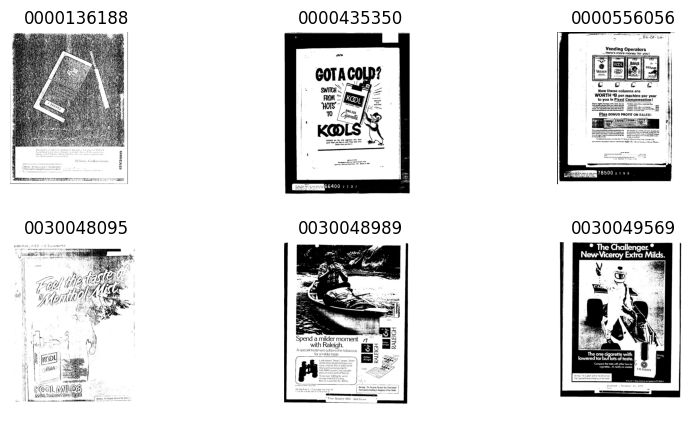

In [107]:
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i in range(6):
    img = cv2.imread(image_paths[i])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(labels[i][:10])
    plt.axis("off")

plt.show()

Since this dataset lacks structured ground truth, I plan to:
- use provided Renaissance PDFs with transcription
- or manually annotate a subset

## Problem Understanding

Historical document OCR presents unique challenges:
- Degraded text quality
- Non-standard fonts and spelling
- Noise and artifacts

To address this, I propose a CNN-RNN-CTC pipeline:
1. CNN extracts visual features
2. Sequence modeling via BiLSTM
3. CTC loss for alignment-free training
4. Beam search decoding
5. LLM-based correction for improved transcription

This hybrid approach combines deep learning with language modeling.

In [108]:
def preprocess(img_path):
    import os

    if not os.path.exists(img_path):
        raise ValueError(f"Path does not exist: {img_path}")

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load image: {img_path}")

    h, w = img.shape
    img = img[0:int(h*0.3), :]

    img = cv2.resize(img, (128, 32))
    img = img / 255.0

    return img

In [109]:
print("Sample path:", image_paths[0])
print("Exists:", os.path.exists(image_paths[0]))

img_test = cv2.imread(image_paths[0])
print("Loaded:", img_test is not None)

Sample path: D:\Gsoc\historical-document-ocr\data\raw\dataset\ADVE\0000136188.jpg
Exists: True
Loaded: True


In [110]:
img = preprocess(image_paths[0])

print("Shape:", img.shape)
print("Min pixel:", img.min())
print("Max pixel:", img.max())

Shape: (32, 128)
Min pixel: 0.0
Max pixel: 1.0


In [111]:
lengths = [len(l) for l in labels]

print("Max length:", max(lengths))
print("Min length:", min(lengths))
print("Avg length:", sum(lengths)/len(lengths))

Max length: 23
Min length: 6
Avg length: 12.179781734635267


In [112]:
# build character set
blank_token = "<BLANK>"
chars = sorted(set("".join(labels)))

if blank_token in chars:
    raise ValueError(f"Blank token {blank_token!r} already exists in labels")

chars.append(blank_token)

char2idx = {c: i for i, c in enumerate(chars)}
idx2char = {i: c for c, i in char2idx.items()}
blank_idx = char2idx[blank_token]

print("Vocab size:", len(chars))
print("Blank index:", blank_idx)

Vocab size: 46
Blank index: 45


In [113]:
import sys

src_path = PROJECT_ROOT / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from data.dataset import OCRDataset

In [114]:
dataset = OCRDataset(image_paths, labels, char2idx)

In [115]:
import torch
from torch.utils.data import DataLoader

def collate_fn(batch):
    batch_images, batch_labels = zip(*batch)

    batch_images = torch.stack(batch_images)

    label_lengths = torch.tensor([len(label) for label in batch_labels])
    batch_labels = torch.cat(batch_labels)

    return batch_images, batch_labels, label_lengths

In [116]:
loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)

In [117]:
for batch in loader:
    batch_images, batch_labels, lengths = batch

    print("Images shape:", batch_images.shape)   # (B, 1, 32, 128)
    print("Labels shape:", batch_labels.shape)
    print("Lengths:", lengths)

    break

Images shape: torch.Size([8, 1, 32, 128])
Labels shape: torch.Size([116])
Lengths: tensor([17, 15, 15, 10, 15, 13, 10, 21])


In [118]:
import os
print(os.path.exists(image_paths[0]))

True


In [119]:
from models.crnn import CRNN


In [120]:
num_classes = len(chars)

model = CRNN(num_classes)

In [121]:
for batch in loader:
    batch_images, batch_labels, batch_label_lengths = batch

    outputs = model(batch_images)

    print("Input shape:", batch_images.shape)
    print("Output shape:", outputs.shape)

    break

Input shape: torch.Size([8, 1, 32, 128])
Output shape: torch.Size([8, 32, 46])


In [122]:
import torch.nn as nn

ctc_loss = nn.CTCLoss(blank=blank_idx, zero_infinity=True)

In [123]:
outputs = model(batch_images)   # (B, T, C)

outputs = outputs.permute(1, 0, 2)  # (T, B, C)

log_probs = outputs.log_softmax(2)

In [124]:
input_lengths = torch.full(
    size=(batch_images.size(0),),
    fill_value=outputs.size(0),  # T
    dtype=torch.long
)

In [125]:
loss = ctc_loss(
    log_probs,
    batch_labels,
    input_lengths,
    batch_label_lengths
)

print("CTC loss:", loss.item())

CTC loss: 8.04071044921875


In [126]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [127]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in loader:
        images, labels, lengths = batch

        optimizer.zero_grad()

        outputs = model(images)  # (B, T, C)
        outputs = outputs.permute(1, 0, 2)  # (T, B, C)

        log_probs = outputs.log_softmax(2)

        input_lengths = torch.full(
            size=(images.size(0),),
            fill_value=outputs.size(0),
            dtype=torch.long
        )

        loss = ctc_loss(
            log_probs,
            labels,
            input_lengths,
            lengths
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 1158.5217
Epoch 2, Loss: 1116.2324
Epoch 3, Loss: 1108.7143
